# Playing Atari with Deep Reinforcement Learning (Deep Q-Network)

Replication of Mnih, Kavukcuoglu, Silver, Graves, Antonoglou, Wierstra and Riedmiller
(2013), *Playing Atari with Deep Reinforcement Learning* (arXiv:1312.5602).

This paper introduced the Deep Q-Network: a neural network trained to approximate the
optimal action-value function Q*, stabilized by two key ideas, experience replay (training
on random minibatches of past transitions) and a periodically updated target network. We
implement DQN from scratch with both mechanisms and train it on a compact grid-world
navigation task (so it runs on CPU without external RL dependencies). We reproduce the
central behavior: the agent's return rises and the number of steps it takes to reach the
goal falls toward the optimal path length as learning proceeds.

In [1]:
import random, collections, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0); random.seed(0); np.random.seed(0)

In [2]:
# Minimal deterministic grid-world: start top-left, reach goal bottom-right.
N = 5
GOAL = (N-1, N-1)
ACTIONS = [(-1,0),(1,0),(0,-1),(0,1)]                    # up, down, left, right
def reset(): return (0, 0)
def step(s, a):
    dr, dc = ACTIONS[a]
    r = min(max(s[0]+dr, 0), N-1); c = min(max(s[1]+dc, 0), N-1)
    ns = (r, c); done = ns == GOAL
    reward = 1.0 if done else -0.02                      # small step penalty, goal reward
    return ns, reward, done
def encode(s):
    v = np.zeros(N*N, np.float32); v[s[0]*N + s[1]] = 1.0; return v
print("grid", N, "x", N, "| optimal steps corner-to-corner:", 2*(N-1))

grid 5 x 5 | optimal steps corner-to-corner: 8


In [3]:
class QNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(N*N, 128), nn.ReLU(), nn.Linear(128, 4))
    def forward(self, x): return self.net(x)

q = QNet(); target = QNet(); target.load_state_dict(q.state_dict())
opt = torch.optim.Adam(q.parameters(), lr=1e-3)
buffer = collections.deque(maxlen=5000)                  # experience replay
GAMMA = 0.95

In [4]:
def act(s, eps):
    if random.random() < eps: return random.randint(0, 3)
    with torch.no_grad():
        return q(torch.tensor(encode(s)).unsqueeze(0)).argmax().item()

def learn(batch=64):
    if len(buffer) < batch: return
    s, a, r, ns, d = zip(*random.sample(buffer, batch))
    s = torch.tensor(np.array(s)); ns = torch.tensor(np.array(ns))
    a = torch.tensor(a); r = torch.tensor(r, dtype=torch.float32); d = torch.tensor(d, dtype=torch.float32)
    qsa = q(s).gather(1, a.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        tgt = r + GAMMA * target(ns).max(1).values * (1 - d)   # target network bootstrap
    loss = nn.functional.smooth_l1_loss(qsa, tgt)
    opt.zero_grad(); loss.backward(); opt.step()

In [5]:
lengths, returns = [], []
for ep in range(400):
    s = reset(); eps = max(0.05, 1.0 - ep/200); done = False; steps = 0; tot = 0.0
    while not done and steps < 100:
        a = act(s, eps); ns, r, done = step(s, a)
        buffer.append((encode(s), a, r, encode(ns), float(done)))
        learn(); s = ns; steps += 1; tot += r
    if ep % 10 == 0: target.load_state_dict(q.state_dict())   # periodic target update
    lengths.append(steps); returns.append(tot)
print(f"avg steps first 20 episodes : {np.mean(lengths[:20]):.1f}")
print(f"avg steps last 20 episodes  : {np.mean(lengths[-20:]):.1f}  (optimal = {2*(N-1)})")
print(f"avg return last 20 episodes : {np.mean(returns[-20:]):.3f}")

avg steps first 20 episodes : 59.0
avg steps last 20 episodes  : 8.6  (optimal = 8)
avg return last 20 episodes : 0.848


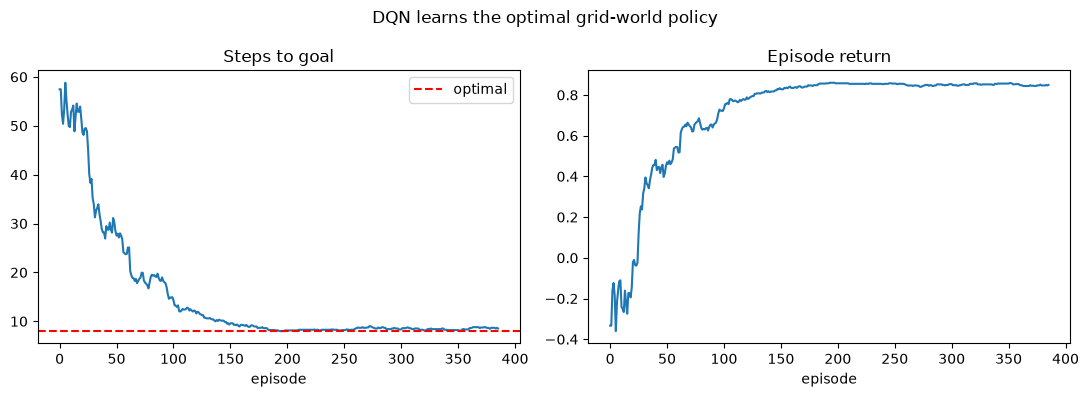

In [6]:
def smooth(v, k=15): return np.convolve(v, np.ones(k)/k, mode="valid")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(smooth(lengths)); ax[0].axhline(2*(N-1), color="r", ls="--", label="optimal")
ax[0].set_title("Steps to goal"); ax[0].set_xlabel("episode"); ax[0].legend()
ax[1].plot(smooth(returns)); ax[1].set_title("Episode return"); ax[1].set_xlabel("episode")
plt.suptitle("DQN learns the optimal grid-world policy"); plt.tight_layout(); plt.show()